In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from mpl_toolkits.mplot3d import Axes3D
from PolynomialApproximators import ( BASE_POLYS,spectral_correction,SpectralPolynomial, Chebyshev)
from PoissonFunctions import eigs_1d_poisson, build_1d_poisson, eigs_2d_poisson, build_2d_poisson
from QSVTSolvers import StandardQSVT,PureSpectralQSVT,SpectrallyBootstrappedQSVT

## Base polynomial and error

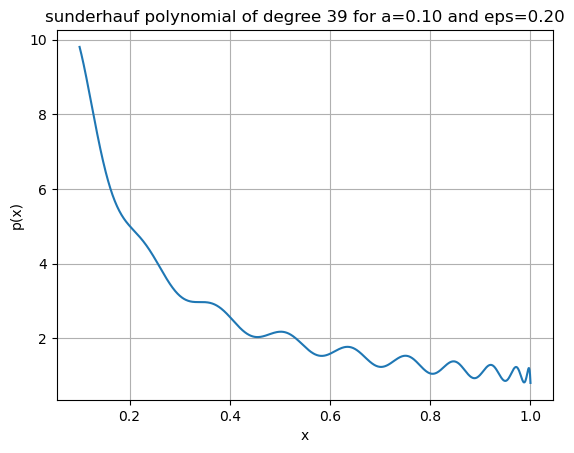

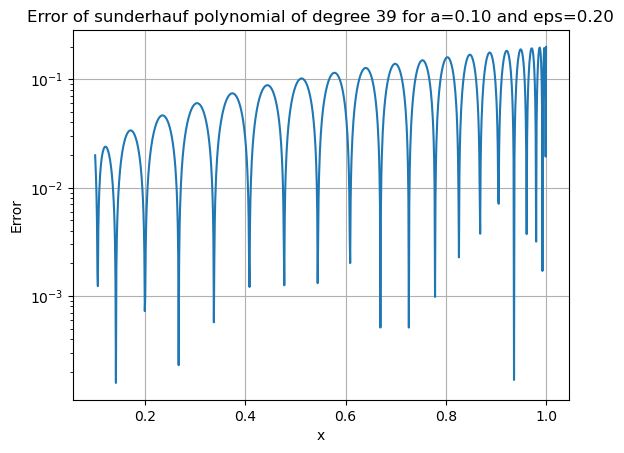

In [2]:
kappa = 10
eps = 0.2
a = 1/kappa
base = 'sunderhauf'
polyClass = BASE_POLYS[base.lower()]

degree   = polyClass.mindegree(eps, a)
poly = polyClass.poly(degree, a)

x = np.linspace(a, 1.0,1000)
y = poly(x)
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('p(x)')
plt.title(f'{base} polynomial of degree {degree} for a={a:.2f} and eps={eps:.2f}')
plt.grid()
plt.show()

error = np.abs(x * poly(x) - 1.0)
plt.plot(x, error)
plt.xlabel('x')
plt.ylabel('Error')
plt.title(f'Error of {base} polynomial of degree {degree} for a={a:.2f} and eps={eps:.2f}')
plt.yscale('log')
plt.grid()
plt.show()

## Pure Spectral Polynomial

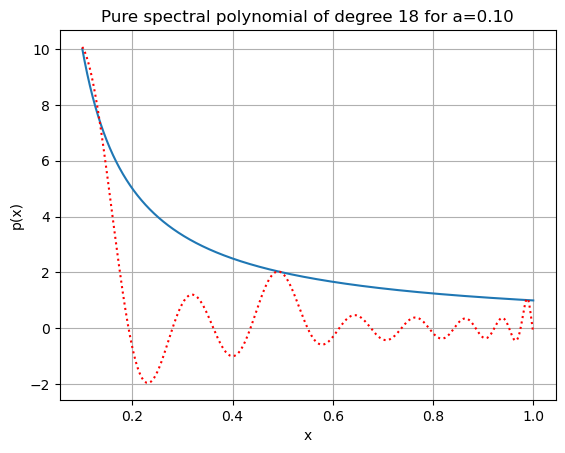

In [3]:
kappa = 10
lam = np.array([1/kappa, 0.5, 1])/1.01
nFactor = 6
d = int(np.shape(lam)[0]*nFactor)
sp = SpectralPolynomial(lam,n_factor=nFactor)
poly = sp.poly(d)
x = np.linspace(1/kappa, 1.0,1000)
y  = 1/x
plt.plot(x, y,'-')
y = poly(x)
plt.plot(x, y,'r:')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.title(f'Pure spectral polynomial of degree {d} for a={1/kappa:.2f}')
plt.grid()
plt.show()


## Spectrally Bootstrapped Polynomial 

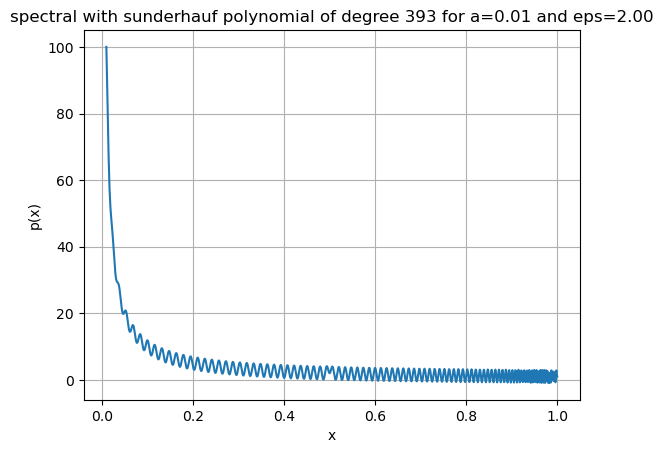

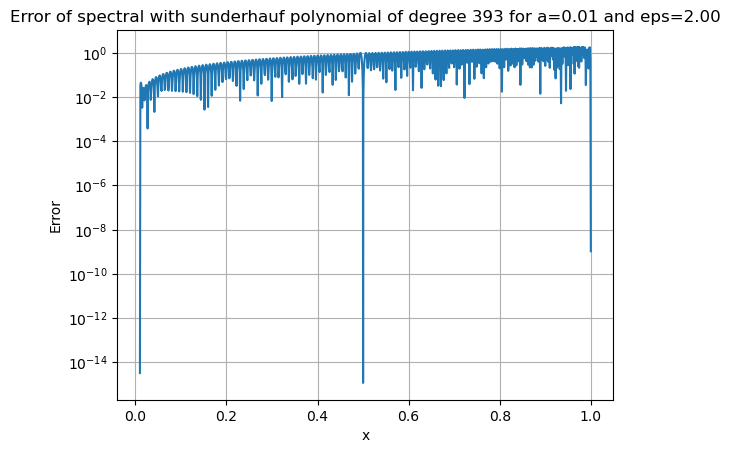

In [4]:
kappa = 100
eps = 2
K = 3
lam = np.array([1/kappa, 0.5, 1])
basePolynomial  = 'sunderhauf' # 'remez' or 'mang' or 'sunderhauf'
polyClass = BASE_POLYS[basePolynomial.lower()]

degree   = polyClass.mindegree(eps, 1/kappa)
poly = polyClass.poly(degree, 1/kappa)

corr = spectral_correction(poly,lam)
coef_H       = poly.coef.copy()
coef_H[1::2] += corr
spectral_poly = Chebyshev(coef_H)


x = np.union1d(np.linspace(1/kappa, 1.0, 1000), lam)
y = spectral_poly(x)
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('p(x)')
plt.title(f'spectral with {basePolynomial} polynomial of degree {degree} for a={1/kappa:.2f} and eps={eps:.2f}')
plt.grid()
plt.show()

error = np.abs(x * spectral_poly(x) - 1.0)
plt.plot(x, error)
plt.xlabel('x')
plt.ylabel('Error')
plt.title(f'Error of spectral with {basePolynomial} polynomial of degree {degree} for a={1/kappa:.2f} and eps={eps:.2f}')
plt.yscale('log')
plt.grid()
plt.show()

## 1D Poisson

### 1D FD Pure Spectral


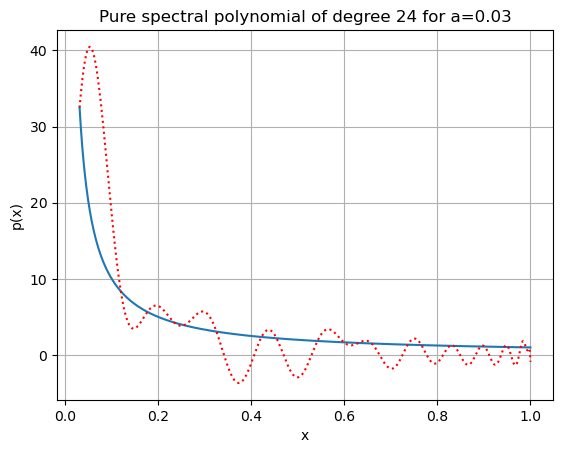

In [5]:
m = 3
lam = eigs_1d_poisson(m)
lam = lam/np.max(lam)/1.01
kappa = 1/np.min(lam)
nFactor = 3
d = int(np.shape(lam)[0]*nFactor)
sp = SpectralPolynomial(lam,n_factor=nFactor)
poly = sp.poly(d)
x = np.linspace(1/kappa, 1.0,1000)
y  = 1/x
plt.plot(x, y,'-')
y = poly(x)
plt.plot(x, y,'r:')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.title(f'Pure spectral polynomial of degree {d} for a={1/kappa:.2f}')
plt.grid()
plt.show()


### 1D FD Spectrally bootstrapped polynomial

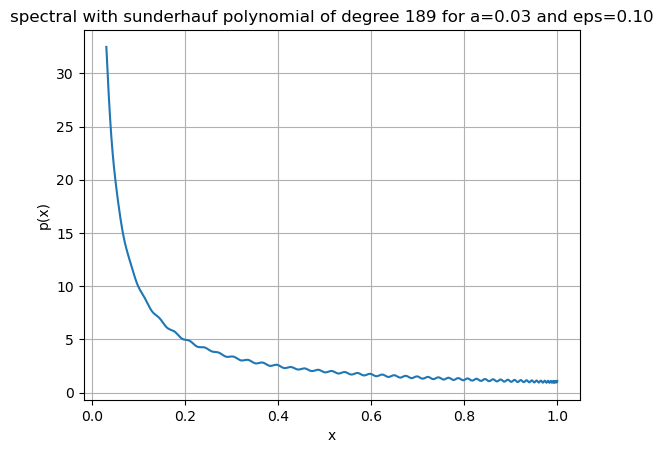

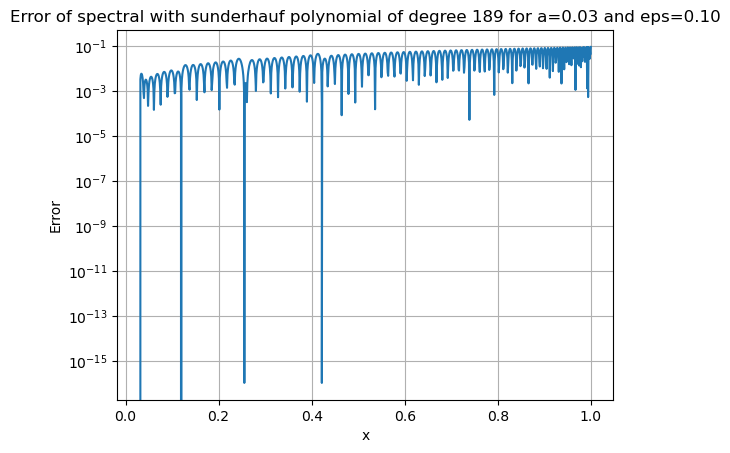

In [6]:
eps = 0.1
m = 3
all_lam  = eigs_1d_poisson(m)
all_lam = all_lam / (1.01*np.max(all_lam))  # Scale eigenvalues to have max < 1
kappa = 1/np.min(all_lam)
a = 1/kappa
N = m**2
K = int(N/2)
lam = all_lam[:K]

a = 1/kappa
basePolynomial  = 'sunderhauf' # 'remez' or 'mang' or 'sunderhauf'
polyClass = BASE_POLYS[basePolynomial.lower()]

degree   = polyClass.mindegree(eps, a)
poly = polyClass.poly(degree, a)

corr = spectral_correction(poly,lam)
coef_H       = poly.coef.copy()
coef_H[1::2] += corr
spectral_poly = Chebyshev(coef_H)


x = np.union1d(np.linspace(a, 1.0, 1000), lam)
y = spectral_poly(x)
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('p(x)')
plt.title(f'spectral with {basePolynomial} polynomial of degree {degree} for a={a:.2f} and eps={eps:.2f}')
plt.grid()
plt.show()

error = np.abs(x * spectral_poly(x) - 1.0)
plt.plot(x, error)
plt.xlabel('x')
plt.ylabel('Error')
plt.title(f'Error of spectral with {basePolynomial} polynomial of degree {degree} for a={a:.2f} and eps={eps:.2f}')
plt.yscale('log')
plt.grid()
plt.show()

## 1D Poisson QSVT

### 1D FD QSVT with pure spectral

m =  4 n_factor =  8
Condition number kappa=117.62580349326262
Constructing pure spectral QSVT solver...
Generated 256 phase angles for degree 255
Circuit width: 10, depth: 513
Running statevector simulation...
Pure Spectral tau =     117.84447442154017
Success probability: 0.8868204594415421
Fidelity: 1.000000


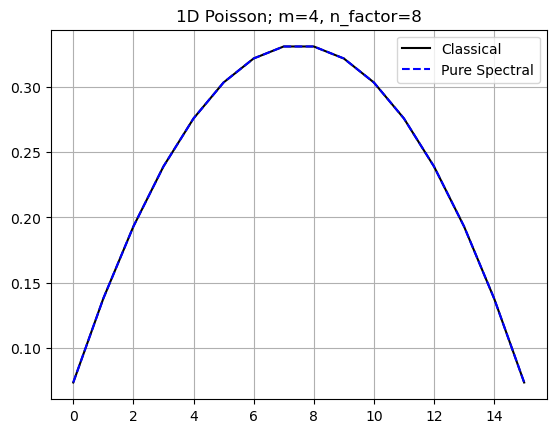

In [7]:
m = 4
n_factor = 8
A, b = build_1d_poisson(m, function_type="uniform")
lam = eigs_1d_poisson(m)
A /= (1.01 * np.max(lam))
lam /= (1.01 * np.max(lam))
kappa = 1.0 / np.min(lam)
u_classical = np.linalg.solve(A, b)
u_classical /= np.linalg.norm(u_classical)

print("m = ", m, "n_factor = ", n_factor)
print(f"Condition number kappa={kappa}")
print("Constructing pure spectral QSVT solver...")
solver = PureSpectralQSVT(A, b, eigenvalues=lam, kappa=kappa, n_factor=n_factor)
u_spectral, success_prob, norm_real = solver.solve()
print("Pure Spectral tau =    ", solver.tau)
print("Success probability:", success_prob)
print(f"Fidelity: {np.abs(np.dot(u_spectral.conj(), u_classical))**2:.6f}")

plt.plot(u_classical, 'k') 
plt.plot(u_spectral, 'b--')
plt.legend(['Classical', 'Pure Spectral'])
plt.grid()
plt.title(f'1D Poisson; m={m}, n_factor={n_factor}')
plt.show()

### Base vs spectrally bootstrapped polynomial

Condition number kappa=32.485071852301616
Generated 88 phase angles for degree 87
Circuit width: 8, depth: 177
Running statevector simulation...
Mang tau =     26.44898564884027
Success probability: 0.9282105716630397
Norm of real solution: 0.9352121344260514
Fidelity:            0.9998385582492152
degree override:  None
computed degree:  87
Generated 88 phase angles for degree 87
Circuit width: 8, depth: 177
Running statevector simulation...
Mang boostrapped tau =     32.61670130378038
Success probability: 0.9253462266376947
Norm of real solution: 0.9419520020852763
Fidelity:            0.9999999999179443


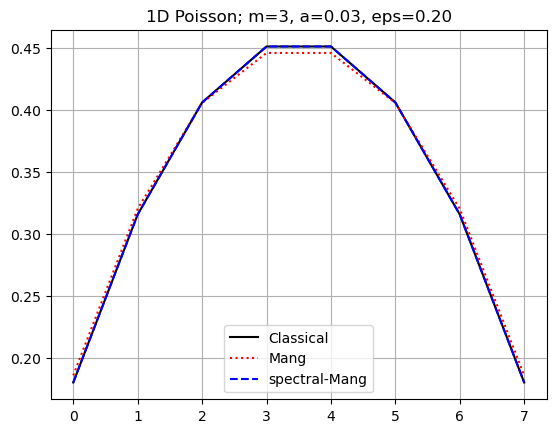

In [8]:
m = 3
eps = 0.2
basePolynomial ='Mang'
A,b  = build_1d_poisson(m, function_type="uniform")
lam = eigs_1d_poisson(m)
A = A / (1.01*np.max(lam))  # Scale to have max singular value < 1
lam = lam / (1.01*np.max(lam))  # Scale eigenvalues accordingly
kappa = 1 / np.min(lam)
a = 1/kappa
print(f"Condition number kappa={kappa}")
# Classical Verification
u_classical = np.linalg.solve(A, b)
u_classical = u_classical / np.linalg.norm(u_classical)


solver_base = StandardQSVT(A, b, kappa, target_error=eps, polyMethod=basePolynomial)
u_base, success_prob, norm_real = solver_base.solve()
print(basePolynomial + " tau =    ", solver_base.tau)
print("Success probability:", success_prob)
print("Norm of real solution:", norm_real)
print("Fidelity:           ", np.abs(np.dot(u_base.conj(), u_classical))**2)

solver_spectralBootstrapped = SpectrallyBootstrappedQSVT(A, b, lam_K=lam, kappa=kappa,
                           target_error=eps, polyMethod=basePolynomial)
u_spectralBootstrapped, success_prob, norm_real = solver_spectralBootstrapped.solve()

print(basePolynomial + " boostrapped tau =    ", solver_spectralBootstrapped.tau)
print("Success probability:", success_prob)
print("Norm of real solution:", norm_real)
print("Fidelity:           ", np.abs(np.dot(u_spectralBootstrapped.conj(), u_classical))**2)

plt.plot(u_classical, 'k') 
plt.plot(u_base, 'r:')
plt.plot(u_spectralBootstrapped, 'b--')
plt.legend(['Classical', basePolynomial, 'spectral-'+basePolynomial])
plt.grid()
plt.title(f'1D Poisson; m={m}, a={a:.2f}, eps={eps:.2f}')
plt.show()

## 2D Poisson QSVT

### Base vs spectrally bootstrapped polynomials

In [9]:
m = 3
eps = 0.1
N = 2**m
K = 2
print(f"Total eigenvalues: {N**2}, using K={K} with eps={eps:.2f} ")

basePolynomial ='Mang'
print(f"Using base polynomial: {basePolynomial}")

A,b  = build_2d_poisson(m, function_type="uniform")
lam = eigs_2d_poisson(m)

A = A / (1.01*np.max(lam))  # Scale to have max singular value < 1
lam = lam / (1.01*np.max(lam))  # Scale eigenvalues accordingly



Total eigenvalues: 64, using K=2 with eps=0.10 
Using base polynomial: Mang
